# 01 — OvaSense-ML Dataset Audit & Feature Classification
**Project**: OvaSense Standalone PCOS Risk-Screening Machine Learning  
**Objective**: Comprehensive clinical data audit, schema inspection, anomaly detection, target leakage analysis, and feature tier classification.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)


Matplotlib is building the font cache; this may take a moment.


## 1. Load Raw Clinical Datasets

In [2]:
raw_excel_path = os.path.join("..", "data", "raw", "PCOS_data_without_infertility.xlsx")
raw_csv_path = os.path.join("..", "data", "raw", "PCOS_infertility.csv")

# Load Instructions sheet
df_instructions = pd.read_excel(raw_excel_path, sheet_name='Instructions')
print("=== INSTRUCTIONS SHEET ===")
display(df_instructions.dropna(how='all'))

# Load Primary Sheet
df_raw = pd.read_excel(raw_excel_path, sheet_name='Full_new')
print(f"\nLoaded Full_new sheet: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()


=== INSTRUCTIONS SHEET ===


,Instructions to be followed :,Unnamed: 1,Unnamed: 2,Unnamed: 3
1,1.0,Kindly ensure that the datas are converted to...,NaN,NaN
2,2.0,Please fill up the entire data set of a patient,NaN,NaN
3,3.0,Manipulated datas if any need to be highlighte...,NaN,NaN
4,4.0,"For every Yes/No questions *** , Indicate Yes...",NaN,NaN
5,5.0,Blood Group indications **,NaN,A+ = 11
6,NaN,NaN,NaN,A- = 12
7,NaN,NaN,NaN,B+ = 13
8,NaN,NaN,NaN,B- = 14
9,NaN,NaN,NaN,O+ =15
10,NaN,NaN,NaN,O- = 16



Loaded Full_new sheet: 541 rows, 45 columns


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


## 2. Target Variable Inspection: `PCOS (Y/N)`

Target Class Distribution:
  PCOS-Negative (0): 364 patients (67.28%)
  PCOS-Positive (1): 177 patients (32.72%)


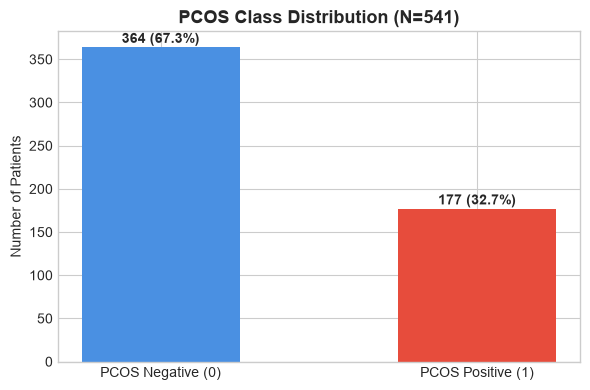

In [3]:
target_col = 'PCOS (Y/N)'
target_counts = df_raw[target_col].value_counts()
target_props = df_raw[target_col].value_counts(normalize=True) * 100

print("Target Class Distribution:")
for val, count in target_counts.items():
    label = "PCOS-Positive (1)" if val == 1 else "PCOS-Negative (0)"
    print(f"  {label}: {count} patients ({target_props[val]:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['PCOS Negative (0)', 'PCOS Positive (1)'], target_counts.values, color=['#4A90E2', '#E74C3C'], width=0.5)
ax.set_title('PCOS Class Distribution (N=541)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Patients')
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 5, f"{int(yval)} ({yval/len(df_raw)*100:.1f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Duplicate Records Verification

In [4]:
exact_dups = df_raw.duplicated().sum()
feature_cols = [c for c in df_raw.columns if c not in ['Sl. No', 'Patient File No.', 'Unnamed: 44']]
clinical_dups = df_raw.duplicated(subset=feature_cols).sum()

print(f"Exact row duplicates: {exact_dups}")
print(f"Clinical feature duplicates (excluding identifiers): {clinical_dups}")


Exact row duplicates: 0
Clinical feature duplicates (excluding identifiers): 0


## 4. Column Inventory & Data Quality Assessment

In [5]:
inventory = []
for i, col in enumerate(df_raw.columns):
    s = df_raw[col]
    s_num = pd.to_numeric(s, errors='coerce')
    nulls = int(s.isnull().sum())
    uniques = int(s.nunique(dropna=False))
    inventory.append({
        '#': i + 1,
        'Column Name': col,
        'Dtype': str(s.dtype),
        'Nulls': nulls,
        'Null %': round(nulls / len(df_raw) * 100, 2),
        'Uniques': uniques,
        'Min': round(s_num.min(), 2) if not s_num.dropna().empty else np.nan,
        'Max': round(s_num.max(), 2) if not s_num.dropna().empty else np.nan,
        'Median': round(s_num.median(), 2) if not s_num.dropna().empty else np.nan,
    })

inv_df = pd.DataFrame(inventory)
display(inv_df)


,#,Column Name,Dtype,Nulls,Null %,Uniques,Min,Max,Median
0,1,Sl. No,int64,0,0.00,541,1.00,541.00,271.00
1,2,Patient File No.,int64,0,0.00,541,1.00,541.00,271.00
2,3,PCOS (Y/N),int64,0,0.00,2,0.00,1.00,0.00
3,4,Age (yrs),int64,0,0.00,29,20.00,48.00,31.00
4,5,Weight (Kg),float64,0,0.00,117,31.00,108.00,59.00
5,6,Height(Cm),float64,0,0.00,50,137.00,180.00,156.00
6,7,BMI,float64,0,0.00,355,12.42,38.90,24.24
7,8,Blood Group,int64,0,0.00,8,11.00,18.00,14.00
8,9,Pulse rate(bpm),int64,0,0.00,11,13.00,82.00,72.00
9,10,RR (breaths/min),int64,0,0.00,8,16.00,28.00,18.00


## 5. Specific Anomaly Detection & Clinical Inconsistencies

In [6]:
print("=== ANOMALY 1: Non-Numeric Entries ===")
print("AMH non-numeric:", df_raw[pd.to_numeric(df_raw['AMH(ng/mL)'], errors='coerce').isna()][['Sl. No', 'AMH(ng/mL)']])
print("II beta-HCG non-numeric:", df_raw[pd.to_numeric(df_raw['II    beta-HCG(mIU/mL)'], errors='coerce').isna()][['Sl. No', 'II    beta-HCG(mIU/mL)']])

print("\n=== ANOMALY 2: Impossible Vital Signs ===")
print("Pulse rate <= 40 bpm (Transposition with RR):")
display(df_raw[df_raw['Pulse rate(bpm) '] <= 40][['Sl. No', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)']])

print("BP Systolic <= 60 mmHg (Missing zero typo):")
display(df_raw[df_raw['BP _Systolic (mmHg)'] <= 60][['Sl. No', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)']])

print("BP Diastolic <= 40 mmHg (Missing zero typo):")
display(df_raw[df_raw['BP _Diastolic (mmHg)'] <= 40][['Sl. No', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)']])

print("\n=== ANOMALY 3: Lab Outliers ===")
print("Vit D3 > 150 ng/mL:")
display(df_raw[df_raw['Vit D3 (ng/mL)'] > 150][['Sl. No', 'Vit D3 (ng/mL)']])

print("FSH > 100 mIU/mL:")
display(df_raw[df_raw['FSH(mIU/mL)'] > 100][['Sl. No', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH']])


=== ANOMALY 1: Non-Numeric Entries ===
AMH non-numeric:      Sl. No AMH(ng/mL)
305     306          a
II beta-HCG non-numeric:      Sl. No II    beta-HCG(mIU/mL)
123     124                  1.99.

=== ANOMALY 2: Impossible Vital Signs ===
Pulse rate <= 40 bpm (Transposition with RR):


,Sl. No,Pulse rate(bpm),RR (breaths/min),BP _Systolic (mmHg),BP _Diastolic (mmHg)
223,224,18,20,120,70
296,297,13,18,110,70


BP Systolic <= 60 mmHg (Missing zero typo):


,Sl. No,BP _Systolic (mmHg),BP _Diastolic (mmHg)
161,162,12,80


BP Diastolic <= 40 mmHg (Missing zero typo):


,Sl. No,BP _Systolic (mmHg),BP _Diastolic (mmHg)
200,201,120,8



=== ANOMALY 3: Lab Outliers ===
Vit D3 > 150 ng/mL:


,Sl. No,Vit D3 (ng/mL)
191,192,6014.66
195,196,5418.60


FSH > 100 mIU/mL:


,Sl. No,FSH(mIU/mL),LH(mIU/mL),FSH/LH
329,330,5052.0,3.68,1372.826087


## 6. Investigation of Beta-HCG Columns (Instruction #10)

In [7]:
bhcg_1 = pd.to_numeric(df_raw['  I   beta-HCG(mIU/mL)'], errors='coerce')
bhcg_2 = pd.to_numeric(df_raw['II    beta-HCG(mIU/mL)'], errors='coerce')

equal_bhcg = (bhcg_1 == bhcg_2).sum()
print(f"Total rows with identical I and II beta-HCG: {equal_bhcg} / {len(df_raw)} ({equal_bhcg/len(df_raw)*100:.2f}%)")
print(f"Correlation between I and II beta-HCG: {bhcg_1.corr(bhcg_2):.4f}")
print(f"Correlation of I beta-HCG with PCOS target: {bhcg_1.corr(df_raw[target_col]):.4f}")


Total rows with identical I and II beta-HCG: 311 / 541 (57.49%)
Correlation between I and II beta-HCG: 0.5337
Correlation of I beta-HCG with PCOS target: -0.0276


## 7. Feature Correlation Ranking with PCOS Label

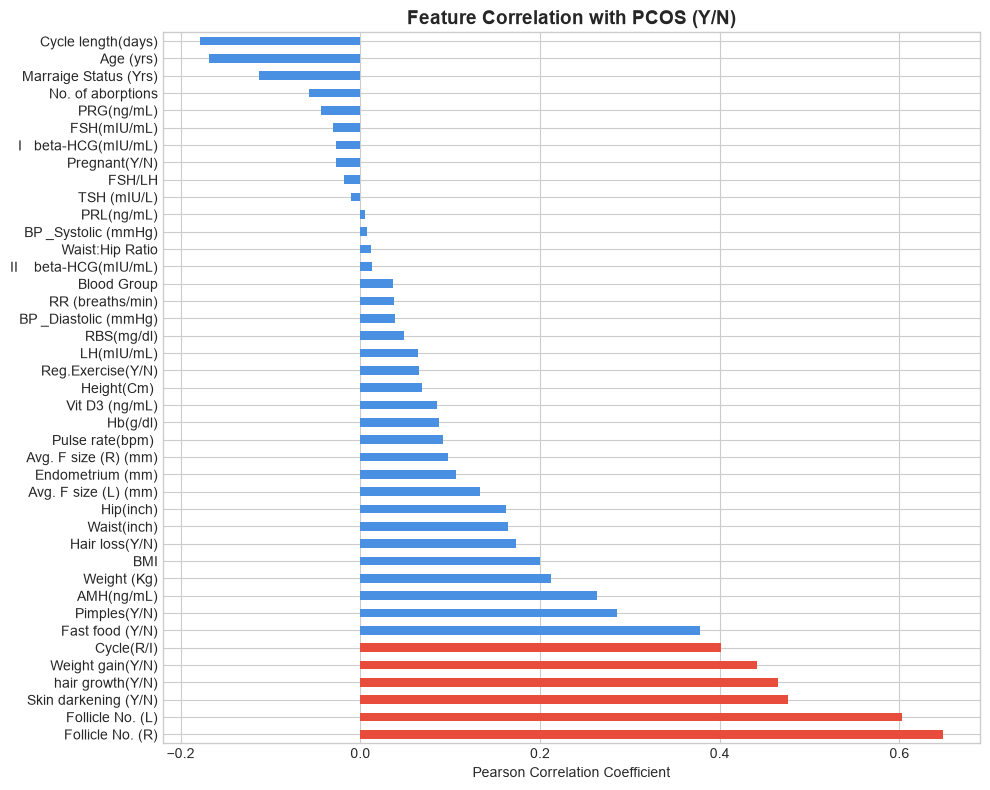

In [8]:
num_df = df_raw.copy()
num_df['AMH(ng/mL)'] = pd.to_numeric(num_df['AMH(ng/mL)'], errors='coerce')
num_df['II    beta-HCG(mIU/mL)'] = pd.to_numeric(num_df['II    beta-HCG(mIU/mL)'], errors='coerce')

num_cols = [c for c in num_df.select_dtypes(include=[np.number]).columns if c not in ['Sl. No', 'Patient File No.']]
corrs = num_df[num_cols].corrwith(num_df[target_col]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
corrs.drop(target_col).plot(kind='barh', ax=ax, color=['#E74C3C' if x > 0.4 else '#4A90E2' for x in corrs.drop(target_col)])
ax.set_title('Feature Correlation with PCOS (Y/N)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()


## 8. Feature Classification Tiers Summary

```
CORE FEATURES (Primary Non-Invasive Screening Model):
- Demographic: Age (yrs)
- Anthropometric: Weight (Kg), Height(Cm) , BMI
- Menstrual/Reproductive: Cycle(R/I), Cycle length(days), Marraige Status (Yrs), Pregnant(Y/N), No. of aborptions
- Symptoms: Weight gain(Y/N), hair growth(Y/N), Skin darkening (Y/N), Hair loss(Y/N), Pimples(Y/N)
- Lifestyle: Fast food (Y/N), Reg.Exercise(Y/N)

EXTENDED FEATURES (Accessible Routine Clinical Model):
- Core Features PLUS:
- Blood Group, Pulse rate(bpm) , RR (breaths/min), Hb(g/dl), BP _Systolic (mmHg), BP _Diastolic (mmHg)
- Hip(inch), Waist(inch), Waist:Hip Ratio, RBS(mg/dl)

FULL CLINICAL BENCHMARK (Comparison Model):
- Core + Extended PLUS:
- FSH(mIU/mL), LH(mIU/mL), FSH/LH, TSH (mIU/L), AMH(ng/mL), PRL(ng/mL), Vit D3 (ng/mL), PRG(ng/mL)
- I beta-HCG(mIU/mL), II beta-HCG(mIU/mL), Avg. F size (L) (mm), Avg. F size (R) (mm), Endometrium (mm)

POTENTIAL LEAKAGE (Excluded from Core Screening):
- Follicle No. (L), Follicle No. (R) [Direct Rotterdam Diagnostic Criteria Ground Truth]

REMOVE:
- Sl. No, Patient File No., Unnamed: 44
```
